In [8]:
import os.path
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Set the seeds for reproducibility
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [15, 10]

In [3]:
mapping = {
    '0': '1 Cent',
    '1': '2 Cent',
    '2': '5 Cent',
    '3': '10 Cent',
    '4': '20 Cent',
    '5': '50 Cent',
    '6': '1 Euro',
    '7': '2 Euro',
}

In [4]:
path_to_dataset = '../../data/coin_tf_dataset'

In [5]:
total_distribution = []
for m in mapping.keys():
    path_to_coin = os.path.join(path_to_dataset, m)
    total_distribution.append(len(os.listdir(path_to_coin)))

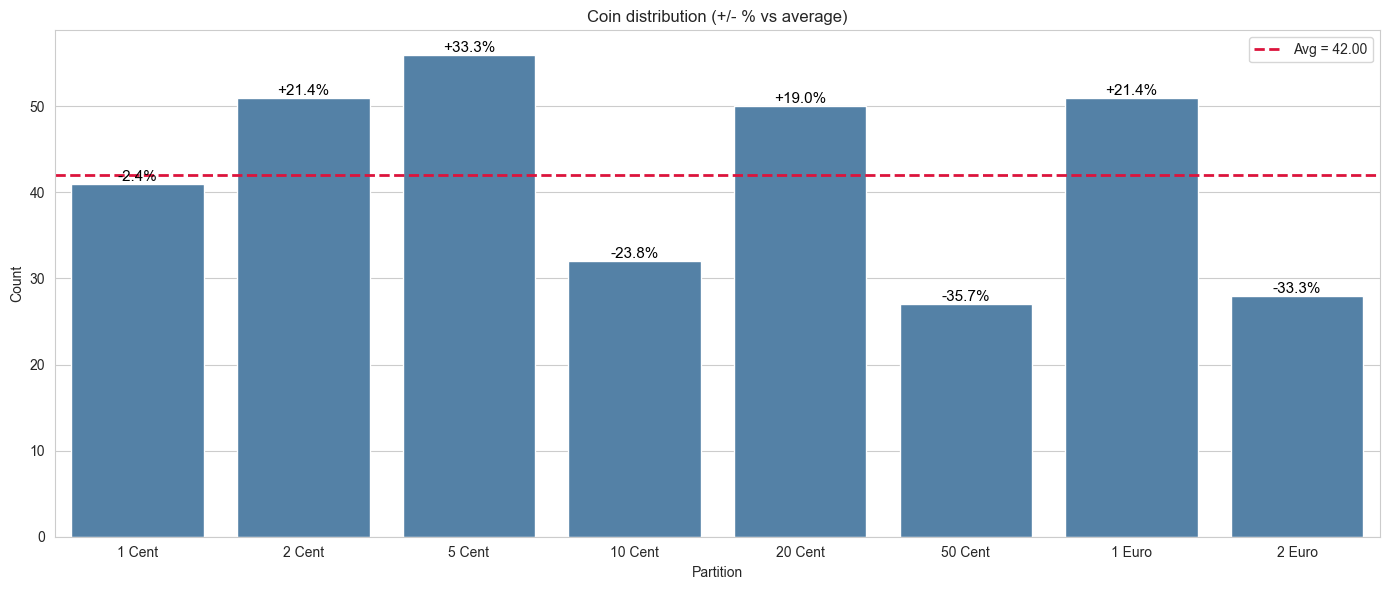

In [6]:
labels = list(mapping.values())  # optional partition names

vals = np.array(total_distribution, dtype=float)
avg = vals.mean()
pct_diff = (vals - avg) / avg * 100  # percent difference vs average

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=labels, y=vals, color="steelblue")

# Average reference line
ax.axhline(avg, color="crimson", linestyle="--", linewidth=2, label=f"Avg = {avg:.2f}")

# Annotate each bar with +/-% vs avg
for i, (v, p) in enumerate(zip(vals, pct_diff)):
    sign = "+" if p >= 0 else ""
    ax.text(
        i, v,
        f"{sign}{p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="black",
    )

ax.set_title("Coin distribution (+/- % vs average)")
ax.set_xlabel("Partition")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

(<Axes: title={'center': 'Clahe Luma'}>,
 Text(0.5, 1.0, 'Clahe Luma'),
 None)

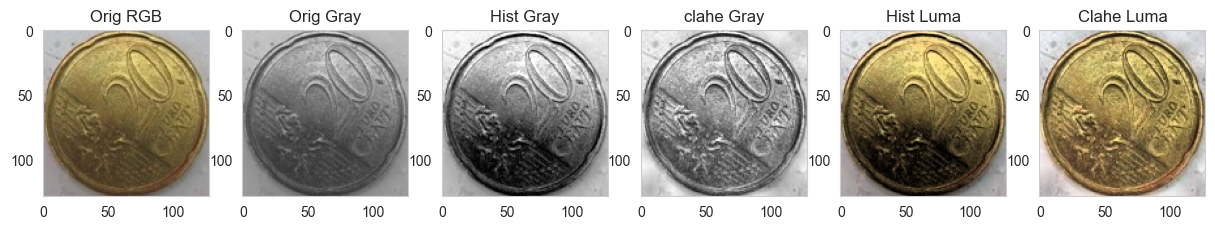

In [33]:
img = cv2.imread(os.path.join(path_to_dataset, '4', '2.jpg'), cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
clipLimit = 2.5

clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=(8,8)).apply(gray)
dst = cv2.equalizeHist(gray)

image_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
hue, saturation, value = cv2.split(image_hsv)

hist_value = cv2.equalizeHist(value)
clahe_value = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=(8,8)).apply(value)
hi_luma = cv2.cvtColor(cv2.merge([hue, saturation, hist_value]), cv2.COLOR_HSV2RGB)
cl_luma = cv2.cvtColor(cv2.merge([hue, saturation, clahe_value]), cv2.COLOR_HSV2RGB)


plt.subplot(161), plt.imshow(img), plt.title('Orig RGB'), plt.grid(False)
plt.subplot(162), plt.imshow(gray, cmap='gray', vmin=0, vmax=255), plt.title('Orig Gray'), plt.grid(False)

plt.subplot(163), plt.imshow(dst, cmap='gray', vmin=0, vmax=255), plt.title('Hist Gray'), plt.grid(False)
plt.subplot(164), plt.imshow(clahe, cmap='gray', vmin=0, vmax=255), plt.title('clahe Gray'), plt.grid(False)

plt.subplot(165), plt.imshow(hi_luma), plt.title('Hist Luma'), plt.grid(False)
plt.subplot(166), plt.imshow(cl_luma), plt.title('Clahe Luma'), plt.grid(False)

In [ ]:
- For GrayScale - bset Hist Gray
- For color - Clache Luma